# 模様解析の基礎：画像を数値で測る

対応章：[模様解析の基礎](../chapters/22_reaction_diffusion_snake.md)．

人工画像の既知の面積・連結・周期を使い，特徴量の実装と限界を学ぶ．実画像との比較は，長さ・前景・境界の規約をそろえてから設計する．配列の第0軸は縦，第1軸は横である．

## ライブラリ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

## 正解が分かる人工模様

斑点の配置間隔と縞の波長はともに32画素である．円の直径と配置間隔は異なる長さなので，斑点画像の最大スペクトルピークが常に配置間隔を返すとは限らない．

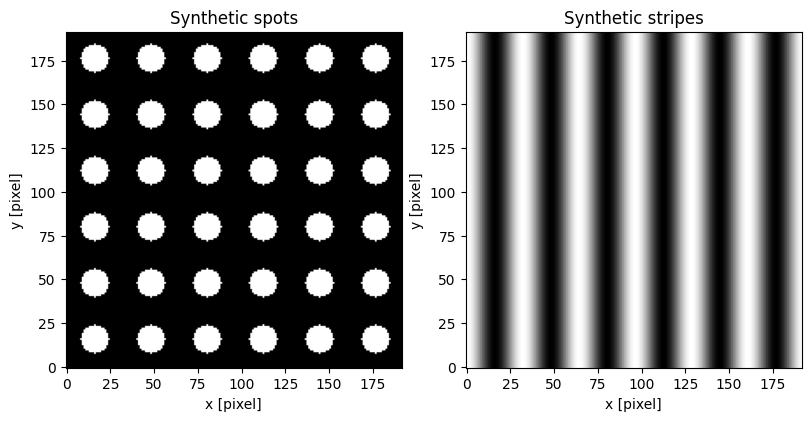

In [2]:
def make_spots(size=192, spacing=32, radius=8):
    yy, xx = np.mgrid[:size, :size]
    image = np.zeros((size, size), dtype=float)
    for cy in range(spacing // 2, size, spacing):
        for cx in range(spacing // 2, size, spacing):
            image[(xx-cx)**2 + (yy-cy)**2 <= radius**2] = 1.0
    return image


def make_stripes(size=192, wavelength=32):
    x = np.arange(size)
    row = 0.5 + 0.5*np.cos(2*np.pi*x/wavelength)
    return np.tile(row, (size, 1))

spots, stripes = make_spots(), make_stripes()
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
for ax, field, title in zip(axes, [spots, stripes], ['Synthetic spots', 'Synthetic stripes']):
    ax.imshow(field, cmap='gray', vmin=0, vmax=1, origin='lower')
    ax.set(title=title, xlabel='x [pixel]', ylabel='y [pixel]')
plt.show()

## 特徴量の定義

面積比と連結成分は明るい側を前景にする．成分数の既定値は8近傍・開いた境界である．周期境界では端のラベルを併合する．

波長は，平均を除いた2次元FFTの最強ピークから求める候補値であり，動径平均のピークではない．`pixel_size=(dy, dx)` で縦横の長さを指定できる．`fftfreq` は角波数でなく空間周波数を返すので，波長はその大きさの逆数である．一定画像は `NaN` とする．ノイズだけでもピークは存在しうるので，値が返れば周期模様があるとは限らない．

In [3]:
def image_array(image):
    array = np.asarray(image, dtype=float)
    if array.ndim != 2 or min(array.shape) < 2 or not np.isfinite(array).all():
        raise ValueError('image must be a finite 2D array with both dimensions >= 2')
    return array


def area_fraction(image, threshold=0.5):
    if not np.isfinite(threshold):
        raise ValueError('threshold must be finite')
    return np.mean(image_array(image) >= threshold)


def component_count(image, threshold=0.5, connectivity=8, periodic=False):
    if connectivity not in (4, 8):
        raise ValueError('connectivity must be 4 or 8')
    if not np.isfinite(threshold):
        raise ValueError('threshold must be finite')
    binary = image_array(image) >= threshold
    structure = ndimage.generate_binary_structure(2, 1 if connectivity == 4 else 2)
    labels, count = ndimage.label(binary, structure=structure)
    if not periodic or count == 0:
        return int(count)
    # 開いた画像のラベルを，周期境界をまたぐ隣接関係で併合する．
    parent = np.arange(count+1)

    def root(label):
        while parent[label] != label:
            parent[label] = parent[parent[label]]
            label = parent[label]
        return label

    offsets = [0] if connectivity == 4 else [-1, 0, 1]
    for axis in (0, 1):
        first, last = np.take(labels, 0, axis=axis), np.take(labels, -1, axis=axis)
        for offset in offsets:
            for a, b in zip(first, np.roll(last, offset)):
                if a and b:
                    parent[root(a)] = root(b)
    return len({root(label) for label in range(1, count+1)})


def spectrum_data(image, pixel_size=1.0, window=False):
    image = image_array(image)
    spacing = np.asarray(pixel_size, dtype=float)
    if spacing.ndim == 0:
        dy = dx = float(spacing)
    elif spacing.shape == (2,):
        dy, dx = spacing
    else:
        raise ValueError('pixel_size must be scalar or (dy, dx)')
    if not np.isfinite([dy, dx]).all() or min(dy, dx) <= 0:
        raise ValueError('pixel spacings must be positive and finite')
    centered = image - image.mean()
    if window:
        centered = centered*np.hanning(image.shape[0])[:, None]*np.hanning(image.shape[1])[None, :]
    power = np.abs(np.fft.fft2(centered))**2 / image.size**2
    power[0, 0] = 0  # ゼロ周波数だけを除く．最初の非ゼロ周波数は残す．
    fy = np.fft.fftfreq(image.shape[0], d=dy)
    fx = np.fft.fftfreq(image.shape[1], d=dx)
    return fx, fy, power


def dominant_wavelength(image, pixel_size=1.0, contrast_tol=1e-12, window=False):
    image = image_array(image)
    if not np.isfinite(contrast_tol) or contrast_tol < 0:
        raise ValueError('contrast_tol must be nonnegative and finite')
    fx, fy, power = spectrum_data(image, pixel_size=pixel_size, window=window)
    if np.ptp(image) <= contrast_tol or power.max() == 0:
        return np.nan  # 周期がない画像を波長0や無限大とは呼ばない．
    iy, ix = np.unravel_index(np.argmax(power), power.shape)
    frequency = np.hypot(fx[ix], fy[iy])
    return 1/frequency if frequency > 0 else np.nan

rows = []
for name, field in [('spots', spots), ('stripes', stripes)]:
    rows.append([name, area_fraction(field), component_count(field), dominant_wavelength(field)])
display(pd.DataFrame(rows, columns=['pattern', 'area fraction', 'components (8, open)', 'wavelength [pixel]']))

,pattern,area fraction,"components (8, open)",wavelength [pixel]
0,spots,0.192383,36,32.0
1,stripes,0.484375,7,32.0


## 手計算できる例と既知の波長を検証する

分散は総パワーなので，波長16と32でも振幅が同じなら一致する．最初の非ゼロ周波数を除く実装だと，幅全体が1周期の例に失敗する．

In [4]:
rows = []
for wavelength in [16, 32, 192]:
    field = make_stripes(wavelength=wavelength)
    measured = dominant_wavelength(field)
    np.testing.assert_allclose(measured, wavelength)
    rows.append([wavelength, measured, field.var()])
assert np.isnan(dominant_wavelength(np.ones((32, 48))))
np.testing.assert_allclose(spectrum_data(stripes)[2].sum(), stripes.var())
display(pd.DataFrame(rows, columns=['known wavelength', 'measured wavelength', 'variance']))

,known wavelength,measured wavelength,variance
0,16,16.0,0.125
1,32,32.0,0.125
2,192,192.0,0.125


## 画像端での成分の分割

図の移動は `np.roll` による周期的な移動である．面積比と窓なしFFTのパワーは不変だが，開いた境界の成分数は端で分かれると変わる．

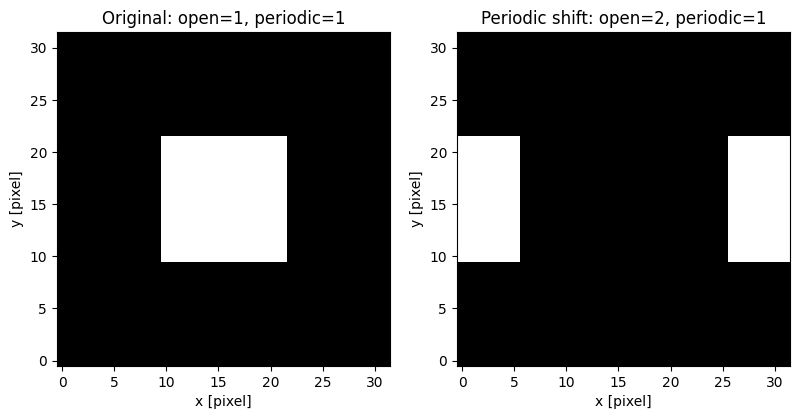

In [5]:
block = np.zeros((32, 32))
block[10:22, 10:22] = 1
wrapped = np.roll(block, 16, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
for ax, field, name in zip(axes, [block, wrapped], ['Original', 'Periodic shift']):
    opened = component_count(field)
    periodic = component_count(field, periodic=True)
    ax.imshow(field, cmap='gray', vmin=0, vmax=1, origin='lower', interpolation='nearest')
    ax.set(title=f'{name}: open={opened}, periodic={periodic}', xlabel='x [pixel]', ylabel='y [pixel]')
np.testing.assert_allclose(spectrum_data(block)[2], spectrum_data(wrapped)[2], atol=1e-14)
plt.show()

## 閾値と移動への感度

二値画像では閾値0.3，0.5，0.7による差は出ない．これは対照例であり，濃淡画像に対する頑健性を保証しない．濃淡縞も同じ表に入れる．開いた境界の成分数と周期境界の成分数を区別する．

In [6]:
rows = []
for threshold in [0.3, 0.5, 0.7]:
    for name, field in [('binary spots', spots), ('gray stripes', stripes)]:
        for shift in [0, 3]:
            shifted = np.roll(field, (shift, shift), axis=(0, 1))
            rows.append([threshold, name, shift, area_fraction(shifted, threshold),
                         component_count(shifted, threshold),
                         component_count(shifted, threshold, periodic=True),
                         dominant_wavelength(shifted)])
display(pd.DataFrame(rows, columns=['threshold', 'image', 'shift', 'area fraction',
                                    'components open', 'components periodic', 'wavelength']))

,threshold,image,shift,area fraction,components open,components periodic,wavelength
0,0.3,binary spots,0,0.192383,36,36,32.0
1,0.3,binary spots,3,0.192383,36,36,32.0
2,0.3,gray stripes,0,0.656250,7,6,32.0
3,0.3,gray stripes,3,0.656250,7,6,32.0
4,0.5,binary spots,0,0.192383,36,36,32.0
5,0.5,binary spots,3,0.192383,36,36,32.0
6,0.5,gray stripes,0,0.484375,7,6,32.0
7,0.5,gray stripes,3,0.484375,7,6,32.0
8,0.7,binary spots,0,0.192383,36,36,32.0
9,0.7,binary spots,3,0.192383,36,36,32.0


## 2次元パワースペクトル

平均を引いた後のパワーを表示するので，中央には元画像の平均のピークは残らない．`log10(P/Pmax + 1e-12)` は相対的な強さを表示するための量であり，原画像の輝度ではない．縞の方向と周波数ベクトルは直交する．

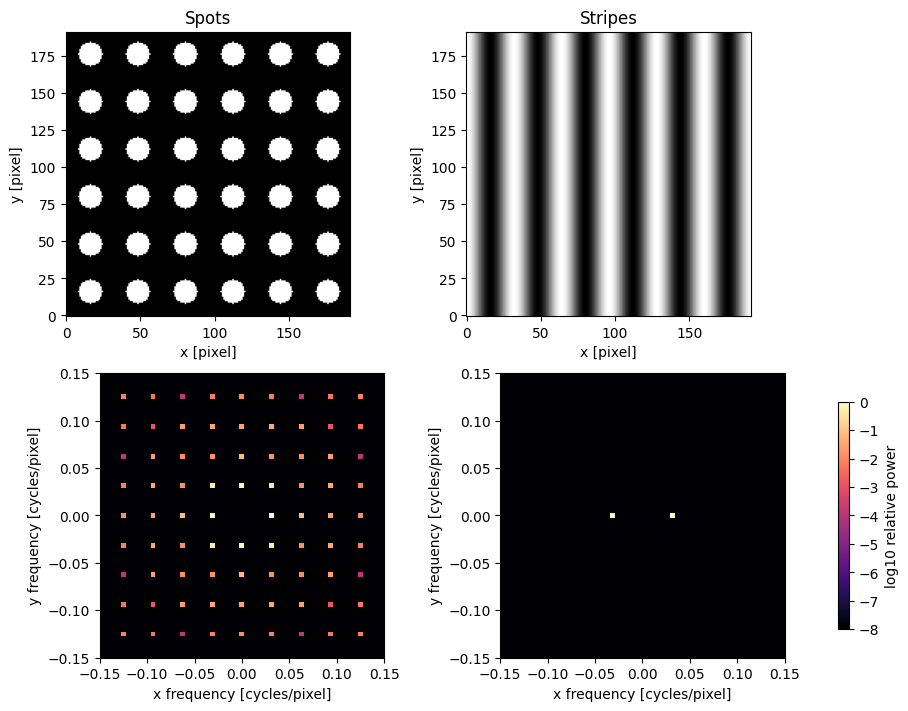

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7), constrained_layout=True)
for col, (name, field) in enumerate([('Spots', spots), ('Stripes', stripes)]):
    fx, fy, power = spectrum_data(field)
    fx, fy, power = np.fft.fftshift(fx), np.fft.fftshift(fy), np.fft.fftshift(power)
    relative_log = np.log10(power/power.max() + 1e-12)
    axes[0, col].imshow(field, cmap='gray', origin='lower', vmin=0, vmax=1)
    axes[0, col].set(title=name, xlabel='x [pixel]', ylabel='y [pixel]')
    im = axes[1, col].pcolormesh(fx, fy, relative_log, cmap='magma', shading='nearest', vmin=-8, vmax=0)
    axes[1, col].set(xlim=(-0.15, 0.15), ylim=(-0.15, 0.15), aspect='equal',
                     xlabel='x frequency [cycles/pixel]', ylabel='y frequency [cycles/pixel]')
fig.colorbar(im, ax=axes[1, :].tolist(), label='log10 relative power', shrink=0.8)
plt.show()

## 課題：実装と検証

1. `make_equal_area_patterns()` を作り，前景画素数が厳密に等しく，連結成分数が異なる2画像を生成する．たとえば64×64画像上の16×16正方形1個と，離れた8×8正方形4個を使い，表と `assert` で確認する．
2. `make_diagonal_touch_example()` を作り，4近傍と8近傍の成分数を比較する．端をまたぐ例も加え，開いた境界と周期境界の違いを検証する．
3. `noise_sensitivity(image, noise_levels, seed)` を作り，面積比，連結成分数，特徴波長をDataFrameにする．同じ基礎乱数を強度倍し，値域を自動的に0から1へ切り詰めない．その後，別seed，閾値，平滑化の影響を比較する．
4. `wavelength_checks()` を作り，一定画像，波長16と32，画像幅が1周期の画像，長方形画像を検証する．画素間隔が違う場合の実長への換算も `assert` で確かめる．
5. 面積比，成分数，波長がそれぞれ区別できない模様と，処理に敏感な条件を，得た数値に基づいて説明する．

In [8]:
# make_equal_area_patterns, make_diagonal_touch_example,
# noise_sensitivity, wavelength_checks を実装する．
# 閾値，近傍，境界規約，画素間隔を記録する．